# Trenowanie modeli regresyjnych

Ten rozdział poświęcony jest uczeniu modeli na podstawie 10 cech wybranych w poprzednim rozdziale.
- podział train/test 80/20,
- preprocessing przez sklearn (encoding + skalowanie),
- trening 3 modeli: LinearRegression, RandomForest, XGBoost,



In [34]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from xgboost import XGBRegressor


In [35]:
data_path = Path('data/final_data.parquet')
target_col = 'tran_cena_brutto'

top10_features = [
    'lok_pow_uzyt',
    'Ulica',
    'coord_y',
    'coord_x',
    'nier_pow_gruntu',
    'dzielnica',
    'tran_rodzaj_trans',
    'tran_rodzaj_rynku',
    'lok_liczba_izb',
    'tran_sprzedajacy',
]

df = pd.read_parquet(data_path)

required_cols = top10_features + [target_col]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f'Brakuje kolumn w danych: {missing_cols}')

model_df = df[required_cols].copy()


## Podział danych na zbiór uczący i terningowy
Dane zostały podzielone w proporcjach 80/20.
Poniżej przedstawione są rozmiary każdego ze zbiorów. Zbiory X_* zawierają cechy na podstawie których modele będą przywidywać y_*

In [36]:
X = model_df[top10_features]
y = model_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

print('X_train:', X_train.shape)
print('X_test: ', X_test.shape)

print("y_train: ", y_train.shape)
print("y_test: ", y_test.shape)


X_train: (3317, 10)
X_test:  (830, 10)
y_train:  (3317,)
y_test:  (830,)


## Preprocesing danych
Zbudowano pipeline przy pomocy bilbioteku `sklearn`, służący do transformacji danych. Został on zbudowany na podstawie zbioru uczącego a następnie wywołany również na zbiorze testowym. Na poniższym obrazie przedstawiono jak przepływają dane w zależności od tego czy dane są liczbowe czy kategoryczne. W przypadku danych liczbowych są one normalizowane, a w przypadku danych kategorycznych są one kodowane przez onehot encoding.

In [37]:
numeric_features = [
    'lok_pow_uzyt',
    'coord_y',
    'coord_x',
    'nier_pow_gruntu',
    'lok_liczba_izb',
]

categorical_features = [
    'Ulica',
    'dzielnica',
    'tran_rodzaj_trans',
    'tran_rodzaj_rynku',
    'tran_sprzedajacy',
]

numeric_transformer = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('encoder', OneHotEncoder(handle_unknown='ignore')),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## Modele
Poniżej przedstawiono wstępnie dobrane parametry modeli:

In [38]:
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(
        n_estimators=400,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1,
    ),
    'XGBoost': XGBRegressor(
        objective='reg:squarederror',
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1,
    ),
}

models


{'LinearRegression': LinearRegression(),
 'RandomForest': RandomForestRegressor(n_estimators=400, n_jobs=-1, random_state=42),
 'XGBoost': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, ...)}

## Wyniki modeli

In [39]:
artifacts_dir = Path('artifacts/models')
artifacts_dir.mkdir(parents=True, exist_ok=True)

results = []
params_records = []
saved_models = {}

for model_name, model in models.items():
    pipe = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', model),
        ]
    )

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    model_path = artifacts_dir / f'{model_name}.joblib'
    joblib.dump(pipe, model_path)

    results.append(
        {
            'model': model_name,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2,
            'model_path': str(model_path),
        }
    )

    params_records.append(
        {
            'model': model_name,
            'params': json.dumps(model.get_params(), ensure_ascii=False, default=str),
        }
    )

    saved_models[model_name] = pipe

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
params_df = pd.DataFrame(params_records)

display(results_df)


,model,MAE,RMSE,R2,model_path
0,XGBoost,90662.347343,173111.821398,0.481516,artifacts/models/XGBoost.joblib
1,RandomForest,93635.067261,177177.745963,0.456875,artifacts/models/RandomForest.joblib
2,LinearRegression,114654.154059,178563.858269,0.448344,artifacts/models/LinearRegression.joblib


Najlepiej wypada XGBoost – ma najniższe błędy (MAE ~83.7k, RMSE ~150.6k) i najwyższe R² = 0.565, więc wyjaśnia najwięcej zmienności cen.

RandomForest i LinearRegression są wyraźnie słabsze: mają wyższe błędy i zbliżone R² (~0.45), przy czym LinearRegression ma największy MAE (~111.6k), czyli najsłabszą trafność średnio.

## Tuning hiperparametrów XGBoost

Poniższy segment zawiera strojenie hiperparametrów modelu z najlepszymi wynikami, w tym przypadku XGBoost. Zostało to zrobione przy pomocy biblioteki `sklearn`, z wykorzystaniem `RandomizedSearchCV`. W tej konfiguracji ta strategia losuje 30 razy parametry, a następnie wykonuje walidację krzyżową i na tej podstawie wybiera najlepszy model.


In [40]:
xgb_tune_pipe = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            XGBRegressor(
                objective='reg:squarederror',
                random_state=42,
                n_jobs=-1,
                verbosity=0,
            ),
        ),
    ]
)

param_distributions = {
    'model__n_estimators': [200, 300, 500, 700, 900],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__max_depth': [3, 4, 5, 6, 8],
    'model__min_child_weight': [1, 3, 5, 7],
    'model__subsample': [0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'model__reg_alpha': [0.0, 0.01, 0.1, 1.0],
    'model__reg_lambda': [0.5, 1.0, 2.0, 5.0],
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_tune_pipe,
    param_distributions=param_distributions,
    n_iter=30,
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=0,
    random_state=42,
    n_jobs=-1,
)

xgb_search.fit(X_train, y_train)

best_xgb_pipe = xgb_search.best_estimator_
best_xgb_preds = best_xgb_pipe.predict(X_test)

xgb_tuned_mae = mean_absolute_error(y_test, best_xgb_preds)
xgb_tuned_rmse = np.sqrt(mean_squared_error(y_test, best_xgb_preds))
xgb_tuned_r2 = r2_score(y_test, best_xgb_preds)

xgb_tuned_path = artifacts_dir / 'XGBoost_tuned.joblib'
joblib.dump(best_xgb_pipe, xgb_tuned_path)

xgb_tuned_result = pd.DataFrame([
    {
        'model': 'XGBoost_tuned',
        'MAE': xgb_tuned_mae,
        'RMSE': xgb_tuned_rmse,
        'R2': xgb_tuned_r2,
        'model_path': str(xgb_tuned_path),
    }
])

results_df_tuned = pd.concat([results_df, xgb_tuned_result], ignore_index=True)
results_df_tuned = results_df_tuned.sort_values('R2', ascending=False).reset_index(drop=True)

print('Najlepsze parametry XGBoost (RandomizedSearchCV):')
display(pd.DataFrame([xgb_search.best_params_]))

print('Wyniki po tuningu:')
display(results_df_tuned)

xgb_tuned_params_df = pd.DataFrame([
    {
        'model': 'XGBoost_tuned',
        'params': json.dumps(xgb_search.best_params_, ensure_ascii=False),
    }
])
params_df_tuned = pd.concat([params_df, xgb_tuned_params_df], ignore_index=True)



Najlepsze parametry XGBoost (RandomizedSearchCV):


,model__subsample,model__reg_lambda,model__reg_alpha,model__n_estimators,model__min_child_weight,model__max_depth,model__learning_rate,model__colsample_bytree
0,0.8,2.0,1.0,500,7,8,0.01,0.6


Wyniki po tuningu:


,model,MAE,RMSE,R2,model_path
0,XGBoost_tuned,89761.883646,160122.500341,0.556405,artifacts/models/XGBoost_tuned.joblib
1,XGBoost,90662.347343,173111.821398,0.481516,artifacts/models/XGBoost.joblib
2,RandomForest,93635.067261,177177.745963,0.456875,artifacts/models/RandomForest.joblib
3,LinearRegression,114654.154059,178563.858269,0.448344,artifacts/models/LinearRegression.joblib


Po dostrojeniu hiperparametrów model XGBoost_tuned osiągnął lepszą jakość predykcji w ujęciu globalnym niż bazowy XGBoost. Wskazuje na to spadek RMSE z 150 571 do 146 714, co oznacza mniejszy wpływ dużych błędów, oraz wzrost R² z 0,5649 do 0,5869. Oznacza to, że model po tuningu wyjaśnia około 58,7% zmienności zmiennej docelowej (wcześniej ok. 56,5%), czyli lepiej odwzorowuje strukturę danych.

Jednocześnie warto zaznaczyć, że MAE dla wersji dostrojonej jest nieco wyższe (85 242 vs 83 707), co sugeruje, że przeciętny błąd bezwzględny minimalnie wzrósł. W praktyce tuning poprawił więc model przede wszystkim pod kątem ograniczenia większych odchyleń (RMSE) i ogólnego dopasowania (R²), kosztem niewielkiego pogorszenia średniego błędu absolutnego.



## Diagnostyka najlepszego modelu na zbiorze testowym

Poniżej generowane są wykresy diagnostyczne tylko dla modelu o najwyższym `R2`.

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

if 'saved_models' not in globals() or 'X_test' not in globals() or 'y_test' not in globals():
    raise RuntimeError('Uruchom wcześniej sekcję treningu modeli, aby zbudować saved_models, X_test i y_test.')

if 'results_df_tuned' in globals() and len(results_df_tuned) > 0:
    ranking_df = results_df_tuned
elif 'results_df' in globals() and len(results_df) > 0:
    ranking_df = results_df
else:
    raise RuntimeError('Brak wyników rankingowych modeli (results_df / results_df_tuned).')

best_model_name = ranking_df.sort_values('R2', ascending=False).iloc[0]['model']

if best_model_name in saved_models:
    best_model = saved_models[best_model_name]
elif best_model_name == 'XGBoost_tuned' and 'best_xgb_pipe' in globals():
    best_model = best_xgb_pipe
else:
    raise RuntimeError(f'Nie znaleziono obiektu modelu dla: {best_model_name}')

y_true = np.asarray(y_test)
y_pred = np.asarray(best_model.predict(X_test))
residuals = y_true - y_pred

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

std_resid = residuals.std(ddof=1)
if np.isclose(std_resid, 0.0):
    standardized_residuals = np.zeros_like(residuals)
else:
    standardized_residuals = residuals / std_resid

scale_location = np.sqrt(np.abs(standardized_residuals))

print(f'Najlepszy model: {best_model_name}')
print(f'MAE: {mae:,.2f} | RMSE: {rmse:,.2f} | R2: {r2:.4f}')

Najlepszy model: XGBoost_tuned
MAE: 89,761.88 | RMSE: 160,122.50 | R2: 0.5564


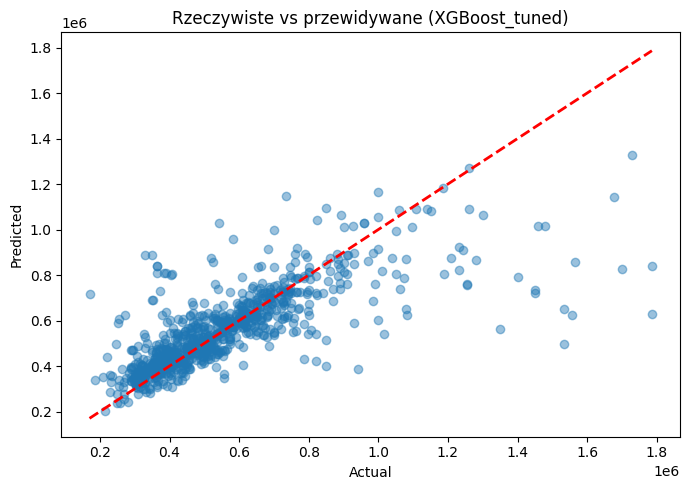

In [42]:
# 1) Actual vs Predicted
plt.figure(figsize=(7, 5))
plt.scatter(y_true, y_pred, alpha=0.45)
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
plt.title(f'Rzeczywiste vs przewidywane ({best_model_name})')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.tight_layout()
plt.show()

Na wykresie widać, że model dobrze odwzorowuje ogólny trend, ponieważ duża część punktów leży blisko linii `y=x`. W górnym zakresie cen punkty częściej znajdują się poniżej tej linii, co wskazuje na tendencję do niedoszacowania najdroższych nieruchomości i większą niepewność predykcji.

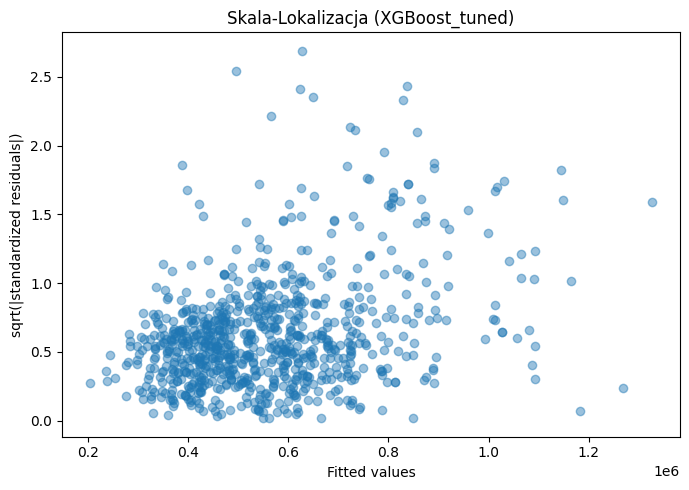

In [43]:
# 3) Scale-Location
plt.figure(figsize=(7, 5))
plt.scatter(y_pred, scale_location, alpha=0.45)
plt.title(f'Skala-Lokalizacja ({best_model_name})')
plt.xlabel('Fitted values')
plt.ylabel('sqrt(|standardized residuals|)')
plt.tight_layout()
plt.show()

Na wykresie widać rosnące wartości `sqrt(|standaryzowanych reszt|)` dla wyższych predykcji, co potwierdza brak stałej wariancji błędu. Pojedyncze punkty o bardzo wysokich wartościach tej miary wskazują na obserwacje odstające lub szczególnie trudne przypadki predykcyjne.

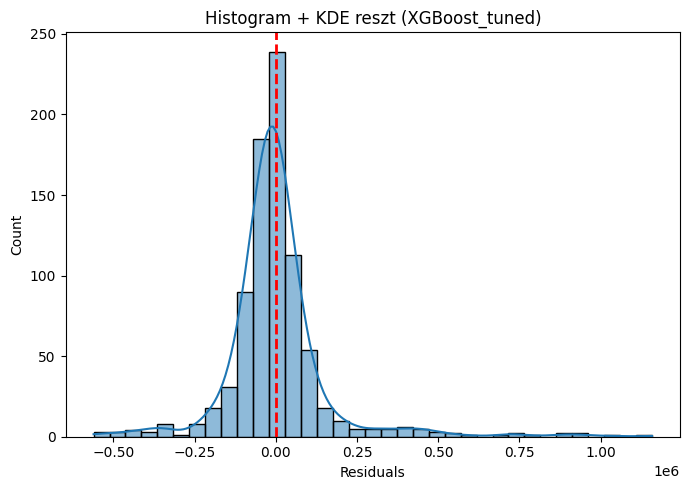

In [44]:
# 4) Histogram + KDE residuals
plt.figure(figsize=(7, 5))
sns.histplot(residuals, kde=True, bins=35)
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.title(f'Histogram + KDE reszt ({best_model_name})')
plt.xlabel('Residuals')
plt.tight_layout()
plt.show()

Na wykresie widać, że większość reszt skupia się blisko zera, co oznacza dobrą trafność dla typowych obserwacji. Jednocześnie rozkład ma prawostronną skośność i długi dodatni ogon, co wskazuje na pojedyncze przypadki dużego niedoszacowania cen.

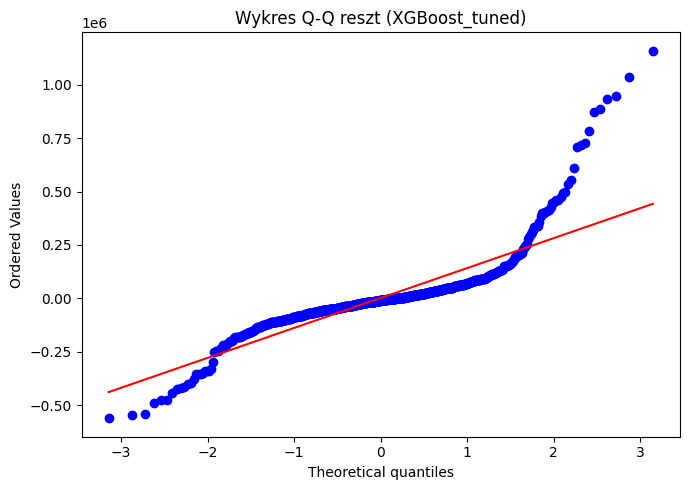

In [45]:
# 5) Q-Q plot residuals
plt.figure(figsize=(7, 5))
stats.probplot(residuals, dist='norm', plot=plt)
plt.title(f'Wykres Q-Q reszt ({best_model_name})')
plt.tight_layout()
plt.show()

Na wykresie widać wyraźne odchylenie punktów od linii odniesienia, szczególnie w prawym ogonie, co oznacza brak normalności rozkładu reszt. Potwierdza to obecność ekstremalnych dodatnich błędów, czyli epizodów silnego niedoszacowania ceny przez model.